In [1]:
import pandas as pd

In [3]:
fruits = pd.read_csv('../Data/fruits.csv')
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


### Feature Set과 Target Set을 Numpy Array로 변경

In [4]:
import numpy as np

#### 연습

In [19]:
# numpy의 column stack과 row stack
testA = np.array([1, 2, 3, 4])
testB = np.array([10, 20, 30, 40])

# 2개의 Array를 묶어서 컬럼기반의 Array로 만들기
combineA = [[i, j] for i,j in zip(testA, testB)]
print(combineA)

#
combineB = np.column_stack((testA, testB))
print(combineB)

#
combineC = np.vstack((testA, testB))
print(combineC)

#
combineD = np.hstack((testA, testB))
print(combineD)

[[np.int64(1), np.int64(10)], [np.int64(2), np.int64(20)], [np.int64(3), np.int64(30)], [np.int64(4), np.int64(40)]]
[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
[[ 1  2  3  4]
 [10 20 30 40]]
[ 1  2  3  4 10 20 30 40]


In [ ]:
# 일반 for 문
test1 = []
# list(range(1, 11)
for i in range(1,11):
    test1.append(i)

# List Compregension
test1 = [i for i in range(1,11) if i % 2 == 0]
test1

[2, 4, 6, 8, 10]

----

In [20]:
# fruits의 feature
fruits_data = np.column_stack((fruits.length, fruits.weight))
fruits_data[:5]

array([[ 25.4, 242. ],
       [ 26.3, 290. ],
       [ 26.5, 340. ],
       [ 29. , 363. ],
       [ 29. , 430. ]])

In [21]:
fruits_data.shape

(49, 2)

In [22]:
# Target
fruits_target = np.array(fruits.name)
fruits_target[:5]

array(['apple', 'apple', 'apple', 'apple', 'apple'], dtype=object)

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        fruits_data,
        fruits_target,
        random_state = 42,
        stratify = fruits_target        # target 비율 고려 층화추출
    )

In [25]:
# kNN 이용한 예측
from sklearn.neighbors import KNeighborsClassifier

In [27]:
# 모델 생성
kn = KNeighborsClassifier()     # n_neighbors = 5 (default)

# 학습
kn.fit(train_input, train_target)

# 검증
print(kn.score(train_input, train_target))
print(kn.score(test_input, test_target))

1.0
1.0


----
#### 수상한과일

In [29]:
# length : 25, weight : 150 과일 예측
kn.predict([[25, 150]])

array(['berry'], dtype=object)

#### 시각화

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

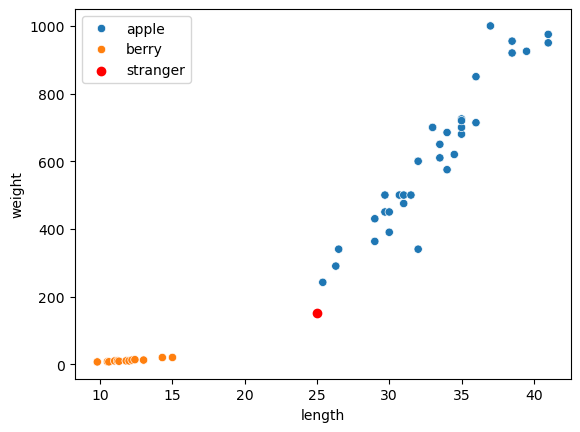

In [39]:
sns.scatterplot(
    data = fruits,
    x = 'length',
    y = 'weight',
    hue = 'name'
)

# 테스트한 애
plt.scatter(25, 150, c= 'red', label = 'stranger')

plt.legend()
plt.show()

#### 이웃 출력

In [46]:
distances, indexies = kn.kneighbors([[25, 150]])              # 거리 arr, 인덱스 arr 두 개 출력

print(distances, indexies)

[[ 92.00086956 130.73859415 137.17988191 138.39320793 140.00603558]] [[11 20 13 22 15]]


In [45]:
# 이웃들의 indexies에 맞는 feature( length, weight ) / target data 출력

print(train_input[indexies[0]])
print(train_target[indexies[0]])

[[ 25.4 242. ]
 [ 14.3  19.7]
 [ 12.4  13.4]
 [ 12.2  12.2]
 [ 26.3 290. ]]
['apple' 'berry' 'berry' 'berry' 'apple']


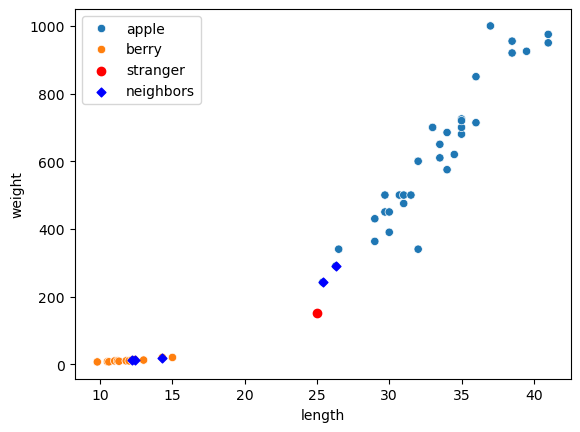

In [51]:
# 이웃 위치 출력
sns.scatterplot(
    data = fruits,
    x = 'length',
    y = 'weight',
    hue = 'name'
)

# 테스트한 애
plt.scatter(25, 150, c= 'red', label = 'stranger')
plt.scatter(train_input[indexies, 0], train_input[indexies, 1], marker= 'D', c = 'blue', label = 'neighbors', s=20)

plt.legend()
plt.show()

In [47]:
train_input[indexies, 0]

array([[25.4, 14.3, 12.4, 12.2, 26.3]])

#### x, y 축 기준

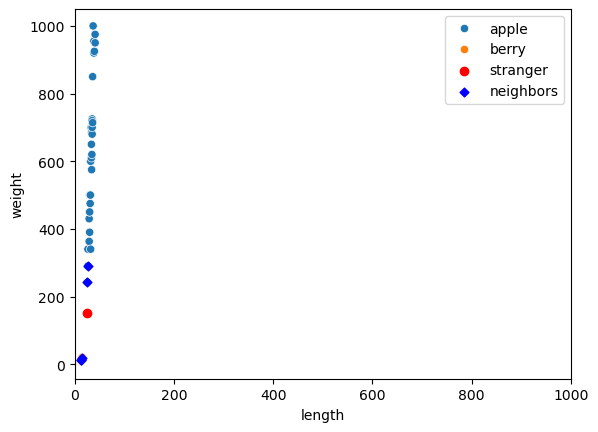

In [52]:
# 이웃 위치 출력
sns.scatterplot(
    data = fruits,
    x = 'length',
    y = 'weight',
    hue = 'name'
)

# 테스트한 애
plt.scatter(25, 150, c= 'red', label = 'stranger')
plt.scatter(train_input[indexies, 0], train_input[indexies, 1], marker= 'D', c = 'blue', label = 'neighbors', s=20)

plt.xlim(0, 1000)
plt.legend()
plt.show()

> data가 Length에는 거의 영향을 받지 않고 weight에서 영향을 많이 받는다.

In [55]:
# length와 weight의 평균과 표준편차
mean = np.mean(train_input, axis = 0)
mean

array([ 26.93333333, 441.98333333])

In [56]:
std = np.std(train_input, axis = 0)
std

array([ 10.09141549, 325.61300692])

#### train_data를 표준점수(z점수) 변경
표준 점수 = (Feature - 평균) / 표준편차

In [57]:
train_scaled = (train_input - mean) / std
train_scaled[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

#### sklearn을 이용

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler = StandardScaler()
scaler.fit(train_input)

,copy,True
,with_mean,True
,with_std,True


In [60]:
train_scaled = scaler.transform(train_input)
train_scaled[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

#### 전처리 데이터로 모델 훈련하기

In [61]:
# 예측할 데이터도 표준점수 변경이 필요
new = ([25, 150] - mean) / std
new

array([-0.19158198, -0.89671889])

In [63]:
kn.fit(train_scaled, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [62]:
test_scaled = (test_input - mean) / std
test_scaled

array([[ 0.79935928,  0.86918109],
       [ 0.74981222,  0.54671239],
       [ 1.39392404,  1.56018542],
       [-1.18252324, -1.29627295],
       [-1.38071149, -1.31992065],
       [ 0.6507181 ,  0.51600109],
       [-1.49962444, -1.32667714],
       [ 0.70026516,  0.40851153],
       [-1.61853739, -1.33589053],
       [ 0.89845341,  1.25307238],
       [ 0.30388865, -0.15964759],
       [ 0.50207691,  0.48528979],
       [ 0.27416042,  0.17817675]])

In [67]:
# 검증
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

#
kn.predict([new])

1.0
1.0


array(['apple'], dtype=object)

#### 시각화

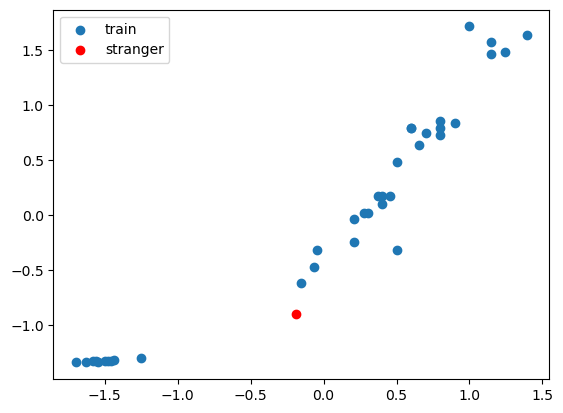

In [75]:
# 이웃 위치 출력
plt.scatter(
    train_scaled[:, 0],
    train_scaled[:, 1],
    label = 'train'
)

# 테스트한 애
plt.scatter(new[0], new[1], c= 'red', label = 'stranger')

plt.legend()
plt.show()